grocery sales trend or pricing optimization

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data

df = pd.read_csv('/content/drive/Shareddrives/Data Science Final Project/Data over 2024 - Final CSV Upload-2.csv')
print(df.head())

        SKU                         item_name  jan_net_sales  feb_net_sales  \
0     50101               EGGS, US XL 1DZN/30       42057.90       43776.18   
1     40101              EGGS, US MED 1DZN/30       25433.21       32214.31   
2   200500+           BEEF, CHUCK ROLL COMMON       20167.40       40299.20   
3    200219        CHICKEN, LEG QUARTER 19.8#       14344.05       19830.30   
4  JHK09901  MILK, GOSSNER WHOLE WHITE 1QT/12       16032.44       15603.04   

   mar_net_sales  apr_net_sales  may_net_sales  jun_net_sales  jul_net_sales  \
0       36563.40       36193.77       26543.43       31798.17       26553.42   
1       43505.25       18717.47       22606.39       25898.90       19804.08   
2       25988.00       23371.40       21511.30       14204.40       26619.90   
3       21406.35       20149.50       20049.75       18733.05       20728.05   
4       15137.48       15734.12       17087.86       16457.32       22041.78   

   aug_net_sales  sep_net_sales  oct_net_sal

In [ ]:
# Making sure column names are correctly formatted

# Create dept code from each category column (first 2 characters)
df['dept_code'] = df['category'].str[:2]

# Check for missing values (NaNs)
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

# Handle missing values
# For sales columns, replace NaN with 0 // fix
sales_cols = [col for col in df.columns if 'net_sales' in col]
for col in sales_cols:
  if df[col].isnull().any():
      print(f"Replacing {df[col].isnull().sum()} missing sales values in {col} with 0")
      df[col] = df[col].fillna(0)
  if (df[col]>250000).any():
      print(f"Replacing {df[col].isnull().sum()} missing sales values in {col} with 250,000")
      df.loc[df[col]>250000, col] = 250000


# For categorical columns, fill with 'Unknown'
cat_cols = ['SKU', 'item_name', 'category', 'dept_code']
for col in cat_cols:
  if col in df.columns and df[col].isnull().any():
      print(f"Replacing {df[col].isnull().sum()} missing values in {col} with 'Unknown'")
      df[col] = df[col].fillna('Unknown')

# Clean sales data - ensure all sales columns are numeric
for col in sales_cols:
  if df[col].dtype == 'object':
      df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)

# Create department name mapping for categories
dept_mapping = {
  'GB': 'Beverages and Drinks',
  'GC': 'Chilled',
  'GF': 'Frozen Foods',
  'GG': 'Grocery Goods',
  'GH': 'Health and Beauty',
  'GI': 'Infant Goods',
  'GM': 'Meat & Poultry',
  'GN': 'Non-Food',
  'GP': 'Produce',
  'GR': 'Rice'
}

# Create department name column
df['dept_name'] = df['dept_code'].map(dept_mapping).fillna('Other')



Missing values per column:
SKU                0
item_name          0
jan_net_sales      0
feb_net_sales      0
mar_net_sales      0
apr_net_sales      0
may_net_sales      1
jun_net_sales      0
jul_net_sales      1
aug_net_sales      0
sep_net_sales      0
oct_net_sales      0
nov_net_sales      0
dec_net_sales      0
total_net_sales    0
category           0
dept_code          0
dtype: int64
Replacing 1 missing sales values in may_net_sales with 0
Replacing 1 missing sales values in jul_net_sales with 0
Replacing 0 missing sales values in total_net_sales with 250,000


In [ ]:
# Features

# Monthly sales columns
monthly_cols = ['jan_net_sales', 'feb_net_sales', 'mar_net_sales',
                'apr_net_sales', 'may_net_sales', 'jun_net_sales',
                'jul_net_sales', 'aug_net_sales', 'sep_net_sales',
                'oct_net_sales', 'nov_net_sales', 'dec_net_sales']

# Create target variable - using total_net_sales as target
y = df['total_net_sales']

# Initialize lists for different feature types
numerical_features = []
categorical_features = []

# Extract department code as categorical feature
categorical_features.append('dept_code')

In [ ]:
# Calculate seasonal sales
# Q1, Q2, Q3, Q4 sales by summing every 3 months
df['q1_sales'] = df[['jan_net_sales', 'feb_net_sales', 'mar_net_sales']].sum(axis=1)
df['q2_sales'] = df[['apr_net_sales', 'may_net_sales', 'jun_net_sales']].sum(axis=1)
df['q3_sales'] = df[['jul_net_sales', 'aug_net_sales', 'sep_net_sales']].sum(axis=1)
df['q4_sales'] = df[['oct_net_sales', 'nov_net_sales', 'dec_net_sales']].sum(axis=1)

# Add quarterly sales as features
numerical_features.extend(['q1_sales', 'q2_sales', 'q3_sales', 'q4_sales'])

# Calculate sales variance (how much the sales fluctuate throughout the year)
df['sales_variance'] = df[monthly_cols].var(axis=1)
numerical_features.append('sales_variance')

# Calculate sales trend (difference between first half and second half of year)
df['first_half'] = df[monthly_cols[:6]].sum(axis=1)
df['second_half'] = df[monthly_cols[6:]].sum(axis=1)
df['half_year_trend'] = df['second_half'] - df['first_half']
numerical_features.append('half_year_trend')


# Average monthly sales for each product (might help with predicting future total sales)
df['avg_monthly_sales'] = df[monthly_cols].mean(axis=1)
numerical_features.append('avg_monthly_sales')

# Add peak month sales (highest sales value for any month for each product)
df['peak_month_sales'] = df[monthly_cols].max(axis=1)
numerical_features.append('peak_month_sales')

# Add month-to-month volatility (how much the sales jump around from month to month)
month_diffs = []
for i in range(1, len(monthly_cols)):
    month_diffs.append(abs(df[monthly_cols[i]] - df[monthly_cols[i-1]]))
df['monthly_volatility'] = pd.concat(month_diffs, axis=1).mean(axis=1)
numerical_features.append('monthly_volatility')

In [ ]:
# One-hot encode categorical features
X_encoded = pd.DataFrame()


# Handle categorical features
if categorical_features:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_cats = encoder.fit_transform(df[categorical_features])
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)
    X_encoded = pd.DataFrame(encoded_cats, columns=encoded_feature_names, index=df.index)

# Combine numerical features
X_numerical = df[numerical_features].copy() if numerical_features else pd.DataFrame(index=df.index)

# Combine all features
X = pd.concat([X_numerical, X_encoded], axis=1)
feature_names = list(X.columns)

print(f"Created {len(feature_names)} features")
print(f"Top features: {feature_names[:len(feature_names)]}")


Created 19 features
Top features: ['q1_sales', 'q2_sales', 'q3_sales', 'q4_sales', 'sales_variance', 'half_year_trend', 'avg_monthly_sales', 'peak_month_sales', 'monthly_volatility', 'dept_code_GB', 'dept_code_GC', 'dept_code_GF', 'dept_code_GG', 'dept_code_GH', 'dept_code_GI', 'dept_code_GM', 'dept_code_GN', 'dept_code_GP', 'dept_code_GR']


In [ ]:
# Exploratory data analysis

# Monthly sales columns
monthly_cols = ['jan_net_sales', 'feb_net_sales', 'mar_net_sales',
                'apr_net_sales', 'may_net_sales', 'jun_net_sales',
                'jul_net_sales', 'aug_net_sales', 'sep_net_sales',
                'oct_net_sales', 'nov_net_sales', 'dec_net_sales']

# Basic statistics for total sales
print("\nTotal Sales statistics:")
print(df['total_net_sales'].describe())




Total Sales statistics:
count     20294.000000
mean       1071.748916
std        6702.040362
min           0.450000
25%          40.010000
50%         125.140000
75%         462.210000
max      250000.000000
Name: total_net_sales, dtype: float64


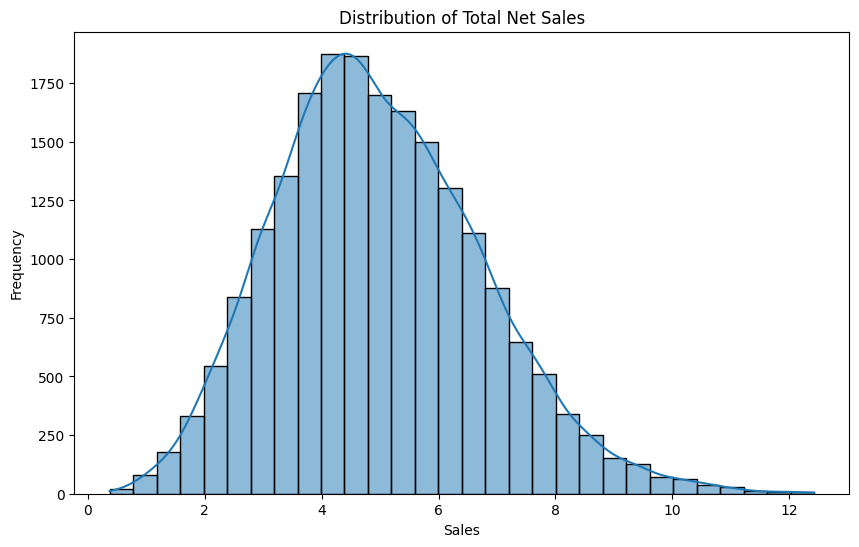

In [ ]:
# Plot sales distribution
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['total_net_sales']), kde=True, bins=30)
plt.title('Distribution of Total Net Sales')
plt.xlabel('Sales') # (sales values)
plt.ylabel('Frequency') # (how often sales values within a certain range occur)
plt.show()

# Shows the distribution of total yearly sales across all products.
# Most products have low total sales, while a few generate significantly higher revenue


In [ ]:
# Percentage of each dept

category_col = 'dept_name'
target_col = 'total_net_sales'

print(f"\nAnalyzing sales by {category_col}")

# Group by the category column
grouped = df.groupby(category_col)[target_col].agg(['sum', 'mean', 'count']).reset_index()
grouped = grouped.sort_values('sum', ascending=False)

# Calculate percentage of total sales
total_sales = grouped['sum'].sum()
grouped['percentage'] = (grouped['sum'] / total_sales * 100).round(2)

# Calculate cumulative percentage
grouped['cumulative_percentage'] = grouped['percentage'].cumsum()

# Print top categories
print(f"\nAll {category_col} by sales:")
print(grouped[['sum', 'percentage', 'cumulative_percentage']])




Analyzing sales by dept_name

All dept_name by sales:
          sum  percentage  cumulative_percentage
3  5995957.30       27.57                  27.57
0  3604117.02       16.57                  44.14
6  3433412.55       15.79                  59.93
7  3095376.21       14.23                  74.16
8  1944299.60        8.94                  83.10
4  1067300.51        4.91                  88.01
1   990731.39        4.56                  92.57
2   690038.14        3.17                  95.74
9   563212.31        2.59                  98.33
5   365627.48        1.68                 100.01


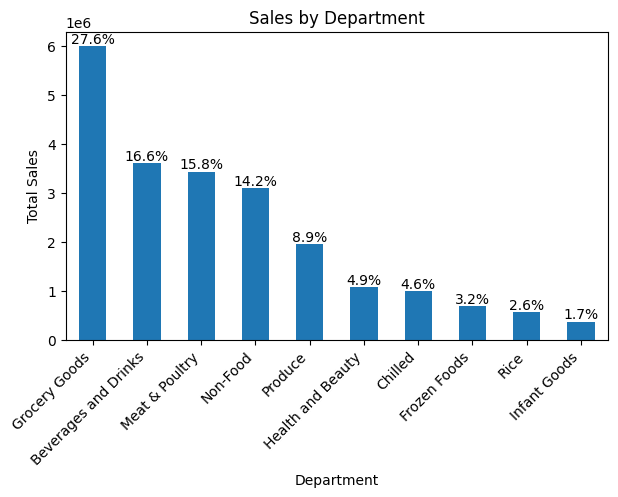

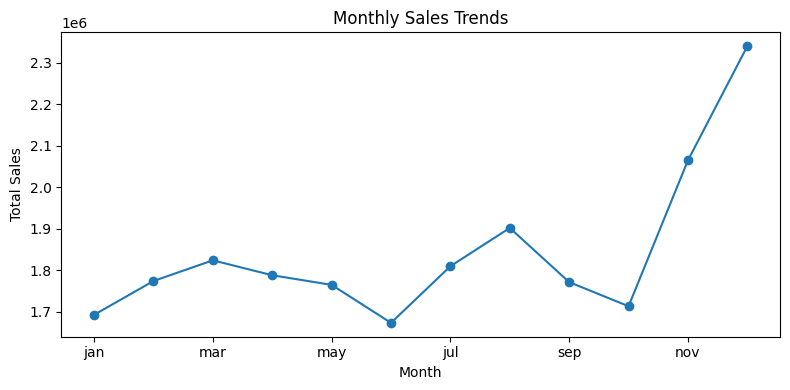

In [ ]:
# Plot sales by department
plt.figure(figsize=(7, 4))
ax = grouped['sum'].plot(kind='bar')
plt.title(f'Sales by Department')
plt.xlabel('Department')
plt.ylabel('Total Sales')

ax.set_xticklabels(grouped[category_col], rotation=45, ha='right')


# Add percentage labels
for i, v in enumerate(grouped['sum']):
    ax.text(i, v, f"{grouped['percentage'].iloc[i]:.1f}%", ha='center', va='bottom')


plt.show()

# Plot monthly sales trends (shows monthy sales data as a line graph)
plt.figure(figsize=(8, 4))
monthly_totals = df[monthly_cols].sum()
monthly_totals.index = [month[:3] for month in monthly_totals.index]  # Shorten month names
monthly_totals.plot(kind='line', marker='o')
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

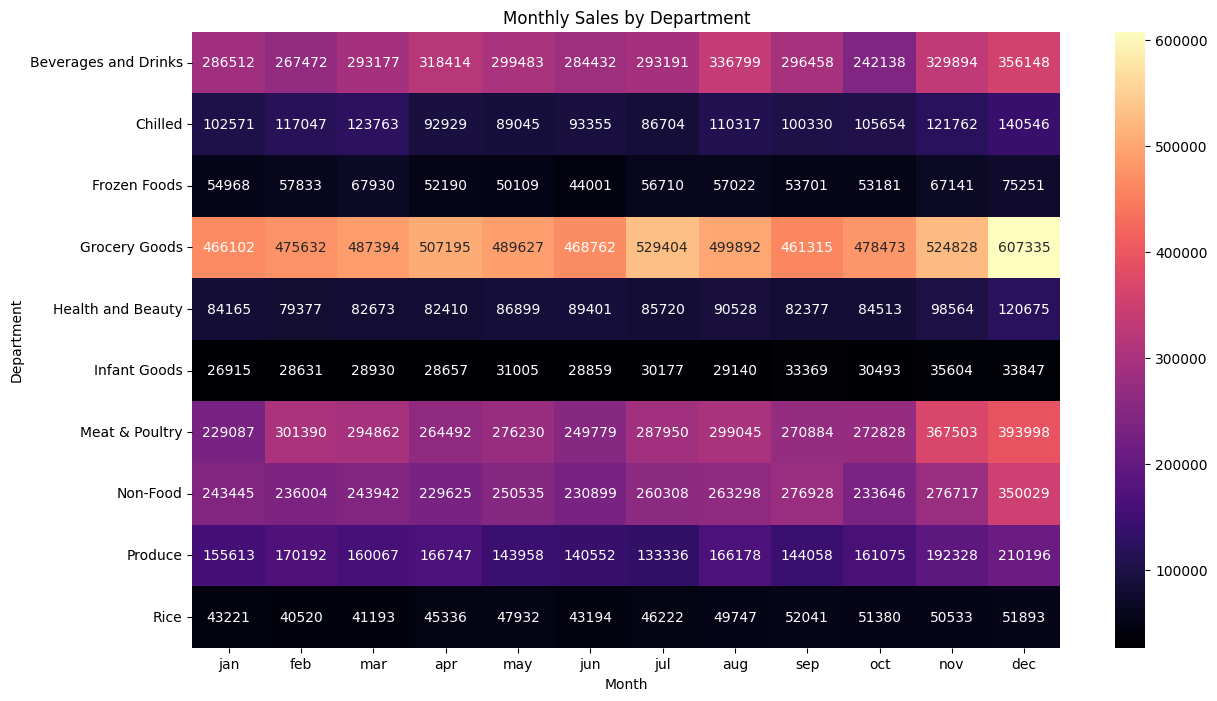

In [ ]:
# Plot monthly sales by department (heatmap)
# First, aggregate monthly sales by department
dept_monthly = df.groupby('dept_name')[monthly_cols].sum()
# Rename columns to shorter month names
dept_monthly.columns = [col[:3] for col in dept_monthly.columns]

plt.figure(figsize=(14, 8))
sns.heatmap(dept_monthly, annot=True, fmt=".0f", cmap="magma")
plt.title('Monthly Sales by Department')
plt.xlabel('Month')
plt.ylabel('Department')
plt.show()

In [ ]:
# Seasonal analysis

monthly_cols = ['jan_net_sales', 'feb_net_sales', 'mar_net_sales',
                'apr_net_sales', 'may_net_sales', 'jun_net_sales',
                'jul_net_sales', 'aug_net_sales', 'sep_net_sales',
                'oct_net_sales', 'nov_net_sales', 'dec_net_sales']

# Create a monthly index
monthly_sales = df[monthly_cols].sum()
monthly_sales.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Identify peak and low seasons
peak_month = monthly_sales.idxmax()
peak_sales = monthly_sales.max()
low_month = monthly_sales.idxmin()
low_sales = monthly_sales.min()

# Calculate seasonality index (peak to low ratio)
seasonality_index = peak_sales / low_sales if low_sales > 0 else float('inf')

# Calculate quarterly sales
quarterly_sales = {
    'Q1': monthly_sales['Jan':'Mar'].sum(),
    'Q2': monthly_sales['Apr':'Jun'].sum(),
    'Q3': monthly_sales['Jul':'Sep'].sum(),
    'Q4': monthly_sales['Oct':'Dec'].sum()
}
peak_quarter = max(quarterly_sales, key=quarterly_sales.get)
low_quarter = min(quarterly_sales, key=quarterly_sales.get)

# Print findings
print(f"Peak sales month: {peak_month} (${peak_sales:.2f})")
print(f"Lowest sales month: {low_month} (${low_sales:.2f})")
print(f"Seasonality index (peak/low ratio): {seasonality_index:.2f}")
print(f"Peak quarter: {peak_quarter} (${quarterly_sales[peak_quarter]:.2f})")
print(f"Lowest quarter: {low_quarter} (${quarterly_sales[low_quarter]:.2f})")



Peak sales month: Dec ($2339918.86)
Lowest sales month: Jun ($1673233.29)
Seasonality index (peak/low ratio): 1.40
Peak quarter: Q4 ($6118173.99)
Lowest quarter: Q2 ($5226051.42)


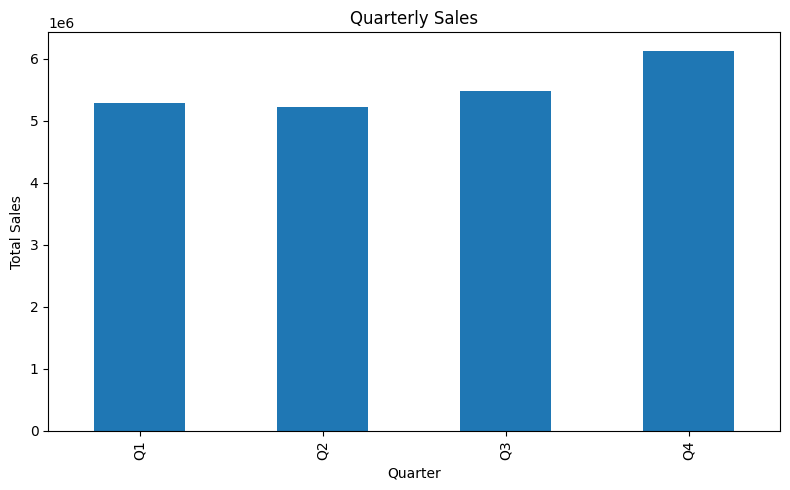

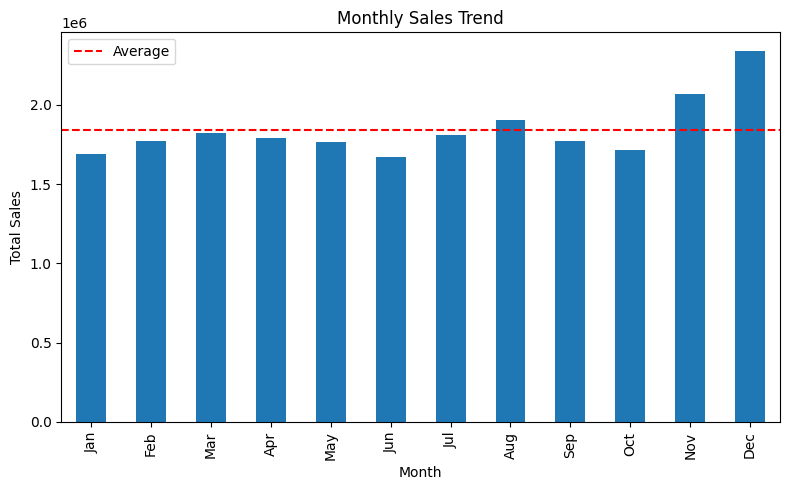

In [ ]:
# Plot quarterly sales
plt.figure(figsize=(8, 5))
pd.Series(quarterly_sales).plot(kind='bar')
plt.title('Quarterly Sales')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Plot monthly sales trend
plt.figure(figsize=(8, 5))
monthly_sales.plot(kind='bar')
plt.axhline(y=monthly_sales.mean(), color='r', linestyle='--', label='Average')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

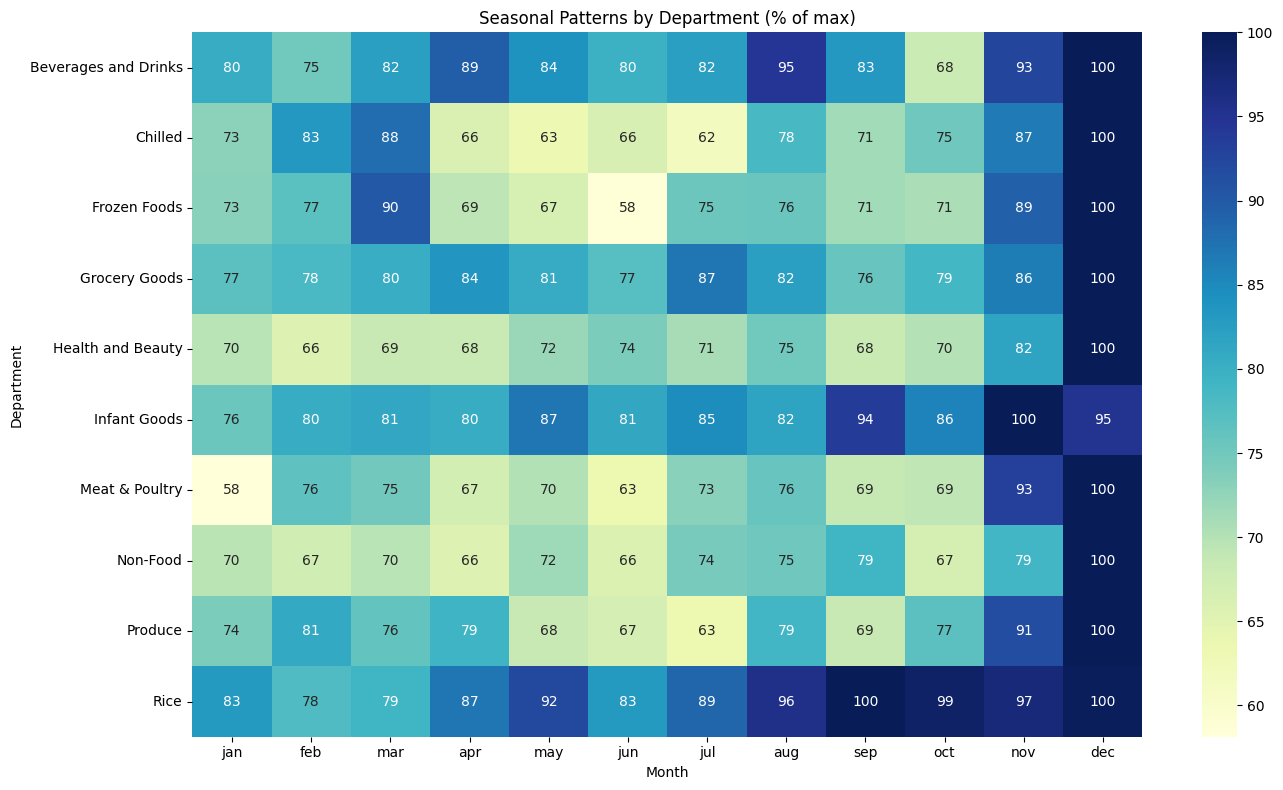

In [ ]:
# Analyze seasonal patterns by department
dept_monthly = df.groupby('dept_name')[monthly_cols].sum()

# Find peak month for each department
dept_peak_months = {}
for dept in dept_monthly.index:
    month_idx = dept_monthly.loc[dept].values.argmax()
    dept_peak_months[dept] = monthly_cols[month_idx][:3]  # Get the month abbreviation

# Normalize the data for better visualization (as percentage of each dept's max)
normalized_data = dept_monthly.copy()
for dept in normalized_data.index:
    normalized_data.loc[dept] = normalized_data.loc[dept] / normalized_data.loc[dept].max() * 100

# Rename columns to shorter month names
normalized_data.columns = [col[:3] for col in normalized_data.columns]

# Plot heatmap of department seasonality
plt.figure(figsize=(14, 8))
sns.heatmap(normalized_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Seasonal Patterns by Department (% of max)')
plt.xlabel('Month')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

# Store seasonality metrics
seasonality_metrics = {
    'peak_month': peak_month,
    'peak_sales': peak_sales,
    'low_month': low_month,
    'low_sales': low_sales,
    'seasonality_index': seasonality_index,
    'quarterly_sales': quarterly_sales,
    'dept_peak_months': dept_peak_months
}

In [ ]:
# Build and train FNN model

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale X features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale y features
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [ ]:
# Simple linear regression as benchmark
benchmark_model = LinearRegression()
benchmark_model.fit(X_train_scaled, y_train_scaled)

# Predict again with seasonal features
benchmark_pred_train = benchmark_model.predict(X_train_scaled)
benchmark_pred_test = benchmark_model.predict(X_test_scaled)

benchmark_pred_train = scaler_y.inverse_transform(benchmark_pred_train)
benchmark_pred_test = scaler_y.inverse_transform(benchmark_pred_test)

benchmark_train_rmse = np.sqrt(mean_squared_error(y_train, benchmark_pred_train))
benchmark_test_rmse = np.sqrt(mean_squared_error(y_test, benchmark_pred_test))
benchmark_train_r2 = r2_score(y_train, benchmark_pred_train)
benchmark_test_r2 = r2_score(y_test, benchmark_pred_test)

print(f"Benchmark Training RMSE: {benchmark_train_rmse:.2f}")
print(f"Benchmark Test RMSE: {benchmark_test_rmse:.2f}")
print(f"Benchmark Training R²: {benchmark_train_r2:.3f}")
print(f"Benchmark Test R²: {benchmark_test_r2:.3f}")

Benchmark Training RMSE: 527.80
Benchmark Test RMSE: 2013.38
Benchmark Training R²: 0.993
Benchmark Test R²: 0.930


In [ ]:
# (try to focus on general patterns instead of memorizing data)

# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=17,
    restore_best_weights=True
)

# Build model
model = Sequential([
    Dense(96, input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.0002)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),
    Dropout(0.3),

    Dense(48, kernel_regularizer=l2(0.0002)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),
    Dropout(0.1),

    Dense(24, kernel_regularizer=l2(0.0002)),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),
    Dropout(0.1),

    Dense(1)  # Output layer for regression
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Print model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_78"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_374 (Dense)                    │ (None, 96)                  │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_280              │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_269 (LeakyReLU)          │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_294 (Dropout)                │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_375 (Dense)                    │ (None, 48)                  │           4,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_281              │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_270 (LeakyReLU)          │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_295 (Dropout)                │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_376 (Dense)                    │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_282              │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_271 (LeakyReLU)          │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_296 (Dropout)                │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_377 (Dense)                    │ (None, 1)                   │              25 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,113 (31.69 KB)

 Non-trainable params: 336 (1.31 KB)

In [ ]:
# Train model
print("\nTraining model...")
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Training model...
Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.7754 - val_loss: 0.0538
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5752 - val_loss: 0.0537
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4629 - val_loss: 0.0546
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4683 - val_loss: 0.0587
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4121 - val_loss: 0.0514
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3035 - val_loss: 0.0654
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2061 - val_loss: 0.0539
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2117 - val_loss: 0.0600
Epoch 9/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1873 - val_loss: 0.0479
Epoch 10/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2627 - val_loss: 0.0541
Epoch 11/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1781 - val_loss: 0.0581
Epoch 12/100
203/203 

In [ ]:
# For validation RMSE and R squared
validation_split=0.2

# Calculate validation
val_size = int(len(X_train_scaled) * validation_split)
val_indices = np.arange(len(X_train_scaled) - val_size, len(X_train_scaled))

# Create validation sets
X_val_scaled = X_train_scaled[val_indices]
y_val_scaled = y_train_scaled[val_indices]
y_val = y_train.iloc[val_indices]

# Remove validation data from training data
X_train_scaled_final = np.delete(X_train_scaled, val_indices, axis=0)
y_train_scaled_final = np.delete(y_train_scaled, val_indices, axis=0)

# Get original scale validation target
if isinstance(y_test, pd.Series):
    train_indices = y_train.index
    val_indices = train_indices[-val_size:]
    y_val = y_train.loc[val_indices]
else:
    y_val = y_train_scaled[-val_size:]
    y_val = scaler_y.inverse_transform(y_val)

# Evaluate model (train, test, and validation)
print("\nEvaluating model...")
y_pred_train = model.predict(X_train_scaled).flatten()
y_pred_test = model.predict(X_test_scaled).flatten()
y_pred_val = model.predict(X_val_scaled)
y_pred_train = scaler_y.inverse_transform(y_pred_train.reshape(-1, 1)).flatten()
y_pred_test = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_pred_val = scaler_y.inverse_transform(y_pred_val.reshape(-1,1)).flatten()

# Calculate metrics (RMSE because it is expressed in sales units)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
val_r2 = r2_score(y_val, y_pred_val)

# Store metrics
metrics = {
    'train_rmse': train_rmse,
    'test_rmse': test_rmse,
    'val_rmse': val_rmse,
    'train_r2': train_r2,
    'test_r2': test_r2,
    'val_r2': val_r2
}

print(f"Training RMSE: {train_rmse:.2f}") # training
print(f"Test RMSE: {test_rmse:.2f}")      # test
print(f"Validation RMSE: {val_rmse:.2f}") # validation
print(f"Training R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Validation R²: {val_r2:.3f}")


Evaluating model...
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training RMSE: 1175.84
Test RMSE: 2653.76
Validation RMSE: 648.31
Training R²: 0.967
Test R²: 0.879
Validation R²: 0.988


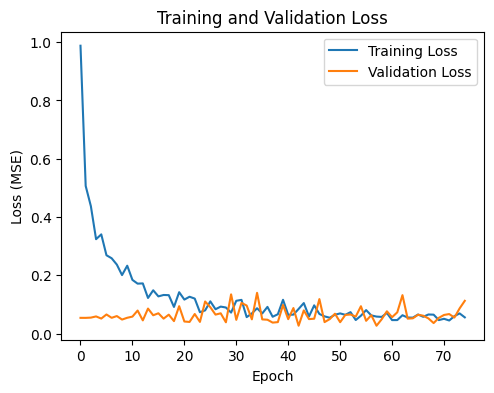

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

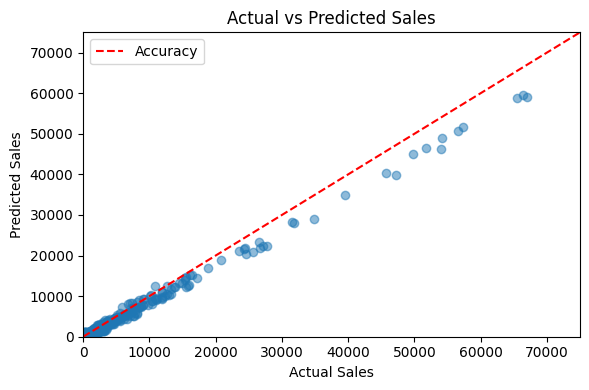

In [ ]:
# Plot actual vs predicted

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Accuracy')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.xlim(0, 75000)
plt.ylim(0, 75000)
plt.tight_layout()
plt.show()

In [ ]:
# Generate base predictions
X_scaled = scaler_X.transform(X)
predicted_sales = model.predict(X_scaled).flatten()
predicted_sales = scaler_y.inverse_transform(predicted_sales.reshape(-1, 1)).flatten()

# Ensure no negative predictions
predicted_sales = np.maximum(predicted_sales, 0)

# Create a DataFrame for storing predictions
predicted_sales_df = pd.DataFrame({
    'SKU': df['SKU'],
    'item_name': df['item_name'],
    'category': df['category'],
    'dept_name': df['dept_name'],
    'predicted_total_sales': predicted_sales,
    'actual_total_sales': df['total_net_sales'],
    'prediction_difference': predicted_sales - df['total_net_sales'],
    'prediction_percent_change': np.where(df['total_net_sales'] != 0,
       ((predicted_sales - df['total_net_sales']) / df['total_net_sales'] * 100).round(2), np.nan)
})

# Generate monthly predictions
monthly_cols_pred = [f"{col[:3]}_pred_sales" for col in monthly_cols]

# Calculate monthly distribution patterns for each department (using averages)
dept_monthly_patterns = df.groupby('dept_name')[monthly_cols].mean()

# Normalize patterns to ensure they sum to 1 (representing proportions)
dept_monthly_patterns = dept_monthly_patterns.div(dept_monthly_patterns.sum(axis=1), axis=0)

# Apply monthly patterns to predicted sales efficiently using vectorized operations
monthly_predictions = predicted_sales_df[['dept_name', 'predicted_total_sales']].merge(dept_monthly_patterns, on='dept_name', how='left')
for j, month in enumerate(monthly_cols):
    monthly_predictions[monthly_cols_pred[j]] = monthly_predictions['predicted_total_sales'] * monthly_predictions[month]

# Drop unnecessary columns
monthly_predictions = monthly_predictions[monthly_cols_pred]

# Add monthly predictions to the results DataFrame
predicted_sales_df = pd.concat([predicted_sales_df, monthly_predictions], axis=1)

# Summarize predictions by department
dept_summary = predicted_sales_df.groupby('dept_name').agg({
    'predicted_total_sales': 'sum',
    'actual_total_sales': 'sum'
}).reset_index()

# Calculate change percentage
dept_summary['change_percent'] = ((dept_summary['predicted_total_sales'] -
                                  dept_summary['actual_total_sales']) /
                                  dept_summary['actual_total_sales'] * 100).round(2)

# Sort by predicted sales
dept_summary = dept_summary.sort_values('predicted_total_sales', ascending=False)

print("\nPredicted Sales by Department:")
print(dept_summary)

635/635 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Predicted Sales by Department:
              dept_name  predicted_total_sales  actual_total_sales  \
3         Grocery Goods           5.464324e+06          5995957.30   
7              Non-Food           3.464698e+06          3095376.21   
6        Meat & Poultry           3.395040e+06          3433412.55   
0  Beverages and Drinks           3.372334e+06          3604117.02   
8               Produce           1.882385e+06          1944299.60   
1               Chilled           1.187570e+06           990731.39   
4     Health and Beauty           8.234832e+05          1067300.51   
2          Frozen Foods           6.697418e+05           690038.14   
9                  Rice           5.195053e+05           563212.31   
5          Infant Goods           4.385196e+05           365627.48   

   change_percent  
3           -8.87  
7           11.93  
6           -1.12  
0           -6.43  
8           -3.18  
1           19.87  
4          -22.8

<ipython-input-378-2d53435bb18f>:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


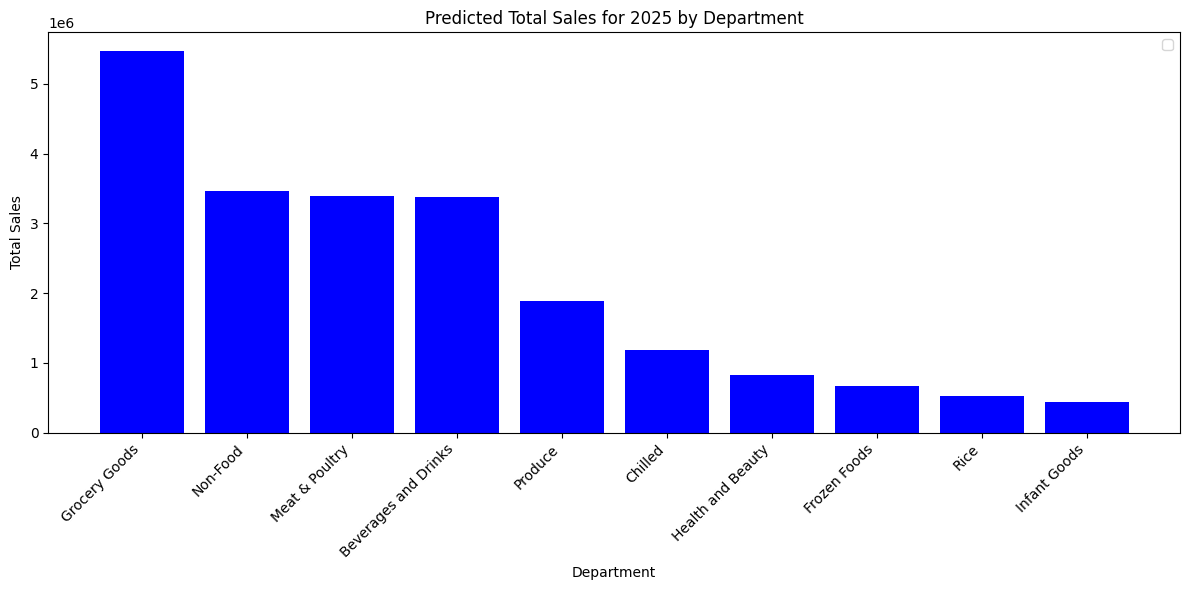

In [ ]:
# Plot predicted sales for each department
plt.figure(figsize=(12, 6))
x = np.arange(len(dept_summary))
plt.bar(x, dept_summary['predicted_total_sales'], color='blue')

plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.title('Predicted Total Sales for 2025 by Department')
plt.xticks(x, dept_summary['dept_name'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

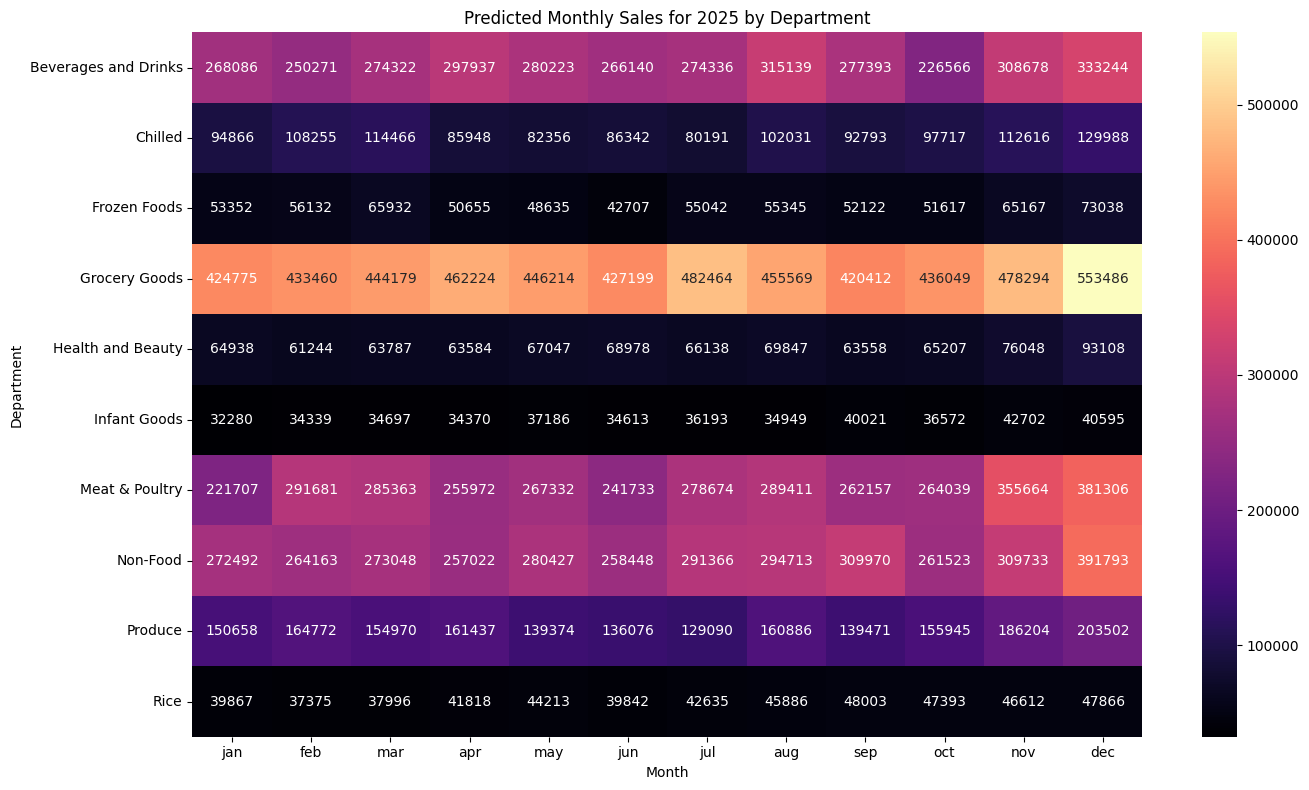

In [ ]:
# Create heatmap of predicted monthly sales for each department for 2025

monthly_by_dept = predicted_sales_df.groupby('dept_name')[monthly_cols_pred].sum()
monthly_by_dept.columns = [col[:3] for col in monthly_by_dept.columns]

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_by_dept, annot=True, fmt=".0f", cmap="magma")
plt.title('Predicted Monthly Sales for 2025 by Department')
plt.xlabel('Month')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

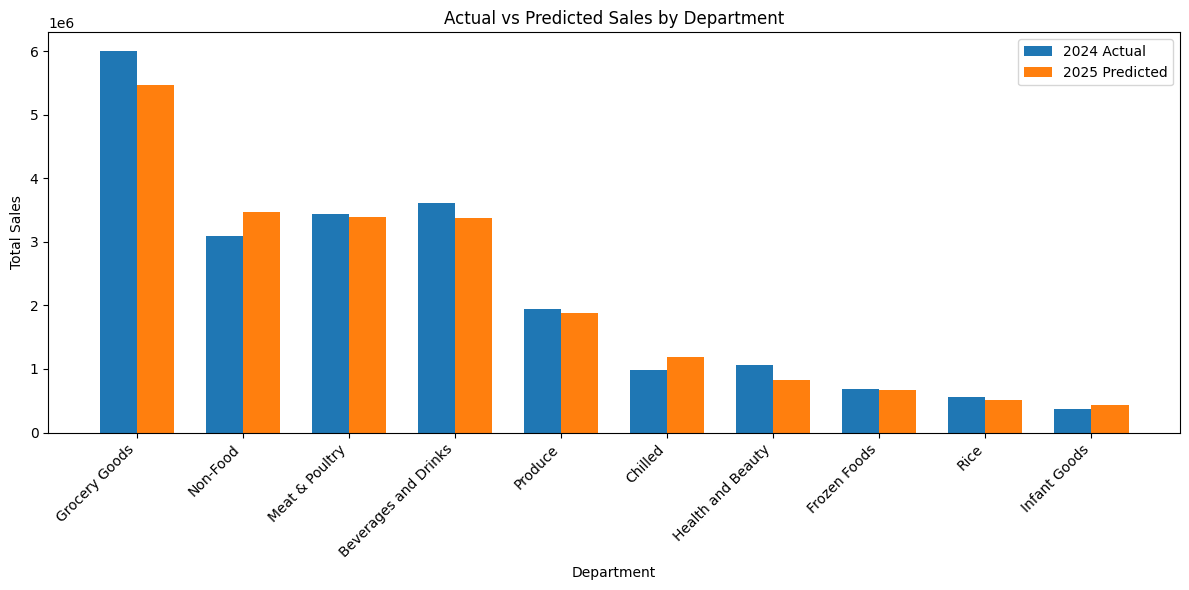

In [ ]:
# Plot actual vs. predicted department sale comparisons
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(dept_summary))

plt.bar(x - bar_width/2, dept_summary['actual_total_sales'], bar_width, label='2024 Actual')
plt.bar(x + bar_width/2, dept_summary['predicted_total_sales'], bar_width, label='2025 Predicted')

plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.title('Actual vs Predicted Sales by Department')
plt.xticks(x, dept_summary['dept_name'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()